In [106]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Python environment:", sys.executable)
print("Packages imported successfully!")

Python environment: c:\Users\suvra_nw8ieuf\AppData\Local\uv-envs\Drug_Assist\Scripts\python.exe
Packages imported successfully!


## Dataset

- Name: Drug Performance Evaluation
- Source: https://www.kaggle.com/datasets/thedevastator/drug-performance-evaluation
- Listed license: CC0 1.0 Universal
- License URL: https://creativecommons.org/publicdomain/zero/1.0/
- Original data: data/raw/drug.csv
- Cleaned data: data/processed/drug_clean.csv
- Original records: 2,219

In [54]:
# Load the dataset
df = pd.read_csv("../data/raw/drug.csv")
display(df.head())

,Condition,Drug,Indication,Type,Reviews,Effective,EaseOfUse,Satisfaction,Information
0,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,994 Reviews,2.52,3.01,1.84,\r\n\t\t\t\t\tLevofloxacin is used to treat a ...
1,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,994 Reviews,2.52,3.01,1.84,\r\n\t\t\t\t\tLevofloxacin is used to treat a ...
2,Acute Bacterial Sinusitis,Moxifloxacin,On Label,RX,755 Reviews,2.78,3.00,2.08,\r\n\t\t\t\t\t This is a generic drug. The ave...
3,Acute Bacterial Sinusitis,Azithromycin,On Label,RX,584 Reviews,3.21,4.01,2.57,\r\n\t\t\t\t\tAzithromycin is an antibiotic (m...
4,Acute Bacterial Sinusitis,Azithromycin,On Label,RX,584 Reviews,3.21,4.01,2.57,\r\n\t\t\t\t\tAzithromycin is an antibiotic (m...


In [55]:
# What are the dimensions of the dataset?
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 2,219
Columns: 9


In [56]:
# What variables and measurements are ther in the dataset?
df.info()
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 2219 entries, 0 to 2218
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Condition     2219 non-null   str    
 1   Drug          2219 non-null   str    
 2   Indication    2219 non-null   str    
 3   Type          2219 non-null   str    
 4   Reviews       2219 non-null   str    
 5   Effective     2219 non-null   float64
 6   EaseOfUse     2219 non-null   float64
 7   Satisfaction  2219 non-null   float64
 8   Information   2219 non-null   str    
dtypes: float64(3), str(6)
memory usage: 156.2 KB


,Condition,Drug,Indication,Type,Reviews,Effective,EaseOfUse,Satisfaction,Information
0,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,994 Reviews,2.52,3.01,1.84,\r\n\t\t\t\t\tLevofloxacin is used to treat a ...
1,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,994 Reviews,2.52,3.01,1.84,\r\n\t\t\t\t\tLevofloxacin is used to treat a ...
2,Acute Bacterial Sinusitis,Moxifloxacin,On Label,RX,755 Reviews,2.78,3.00,2.08,\r\n\t\t\t\t\t This is a generic drug. The ave...
3,Acute Bacterial Sinusitis,Azithromycin,On Label,RX,584 Reviews,3.21,4.01,2.57,\r\n\t\t\t\t\tAzithromycin is an antibiotic (m...
4,Acute Bacterial Sinusitis,Azithromycin,On Label,RX,584 Reviews,3.21,4.01,2.57,\r\n\t\t\t\t\tAzithromycin is an antibiotic (m...


In [57]:
#What conditions, categories, and groups exist?
for column in ["Condition", "Drug", "Indication", "Type"]:
    print(f"\n{column}: {df[column].nunique()} unique values")

    if column != "Drug":
        print(df[column].unique().tolist())


Condition: 37 unique values
['Acute Bacterial Sinusitis', 'adenocarcinoma of pancreas', 'Atopic Dermatitis', 'back pain', 'Bacterial Conjunctivitis', 'Bacterial Urinary Tract Infection', 'biliary calculus', 'chickenpox', 'colorectal cancer', 'depression', 'diverticulitis of gastrointestinal tract', 'edema', 'endometriosis', 'fever', 'fibromyalgia', 'flatulence', 'furunculosis', 'gastroesophageal reflux disease', 'genital herpes simplex', 'gout', 'hemorrhoids', 'herpes zoster', 'hypercholesterolemia', 'hypertension', 'impetigo', 'Infantile Autism', 'Influenza', "meniere's disease", 'oral candidiasis', 'Pharyngitis due to Streptococcus Pyogenes', 'prevention of cerebrovascular accident', 'pyelonephritis', 'scabies', 'Sleepiness Due To Obstructive Sleep Apnea', 'sore throat', 'vertigo', 'vulvovaginal candidiasis']

Drug: 470 unique values

Indication: 3 unique values
['On Label', 'Off Label', '\r\n']

Type: 4 unique values
['RX', 'OTC', 'RX/OTC', '\r\n']


In [58]:
#How many observations are in each group?
for column in ["Condition", "Indication", "Type"]:
    print(f"\nRecords per {column}:")
    display(df[column].value_counts(dropna=False))

print("\nTop 10 drug names by number of records:")
display(df["Drug"].value_counts().head(10))


Records per Condition:


Condition
fever                                        308
hypertension                                 236
Atopic Dermatitis                            209
endometriosis                                163
Bacterial Urinary Tract Infection            131
gastroesophageal reflux disease              131
back pain                                    123
gout                                         110
Pharyngitis due to Streptococcus Pyogenes     83
vertigo                                       81
flatulence                                    76
Acute Bacterial Sinusitis                     65
hypercholesterolemia                          59
hemorrhoids                                   53
diverticulitis of gastrointestinal tract      48
Bacterial Conjunctivitis                      42
edema                                         41
prevention of cerebrovascular accident        38
depression                                    32
vulvovaginal candidiasis                      29
fibromyalg


Records per Indication:


Indication
On Label     1723
Off Label     465
\r\n           31
Name: count, dtype: int64


Records per Type:


Type
RX        1401
OTC        737
RX/OTC      74
\r\n         7
Name: count, dtype: int64


Top 10 drug names by number of records:


Drug
Acetaminophen                    114
Ibuprofen                         73
Diphenhydramine Hcl               58
Aspirin                           42
Sulfamethoxazole-Trimethoprim     40
Amoxicillin                       34
Levonorgestrel-Ethinyl Estrad     32
Simethicone                       32
Norethindrone-Ethin Estradiol     30
Hydrocortisone                    28
Name: count, dtype: int64

In [59]:
##Check for missing values
# Detect empty strings, spaces, and line breaks without changing df

blank_counts = df.apply(
    lambda column: column.map(
        lambda value: isinstance(value, str) and value.strip() == ""
    ).sum()
)

missing_summary = pd.DataFrame({
    "Missing (NaN)": df.isna().sum(),
    "Blank text": blank_counts
})

missing_summary["Total missing or blank"] = missing_summary.sum(axis=1)

display(missing_summary)

,Missing (NaN),Blank text,Total missing or blank
Condition,0,0,0
Drug,0,0,0
Indication,0,31,31
Type,0,7,7
Reviews,0,0,0
Effective,0,0,0
EaseOfUse,0,0,0
Satisfaction,0,0,0
Information,0,0,0


In [60]:
#Check for inconsistencies in the data

for column in ["Condition", "Drug", "Indication", "Type"]:
    labels = pd.DataFrame({
        "original": df[column].dropna().unique()
    })

    labels["normalized"] = (
        labels["original"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.casefold()
    )

    variants = labels[
        labels.duplicated("normalized", keep=False)
    ].sort_values("normalized")

    print(f"\n{column}: label variations")
    display(variants)


Condition: label variations


,original,normalized



Drug: label variations


,original,normalized



Indication: label variations


,original,normalized



Type: label variations


,original,normalized


In [61]:
#Check for duplicates in the data

duplicate_count = df.duplicated().sum()

print(f"Extra duplicate rows: {duplicate_count:,}")
print(f"Rows remaining if removed: {len(df) - duplicate_count:,}")

# Show matching rows together, including the first occurrence
display(
    df[df.duplicated(keep=False)]
    .sort_values(["Condition", "Drug"])
    .head(20)
)

Extra duplicate rows: 466
Rows remaining if removed: 1,753


,Condition,Drug,Indication,Type,Reviews,Effective,EaseOfUse,Satisfaction,Information
13,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,353 Reviews,3.04,3.37,2.34,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...
14,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,353 Reviews,3.04,3.37,2.34,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...
15,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,353 Reviews,3.04,3.37,2.34,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...
16,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,353 Reviews,3.04,3.37,2.34,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...
36,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,11 Reviews,2.33,3.67,3.00,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...
37,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,11 Reviews,2.33,3.67,3.00,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...
38,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,11 Reviews,2.33,3.67,3.00,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...
41,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,5 Reviews,3.00,5.00,3.00,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...
42,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,5 Reviews,3.00,5.00,3.00,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...
43,Acute Bacterial Sinusitis,Amoxicillin,On Label,RX,5 Reviews,3.00,5.00,3.00,\r\n\t\t\t\t\tAmoxicillin is used to treat a w...


In [62]:
print("Extra duplicate rows:", df.duplicated().sum())

Extra duplicate rows: 466


In [63]:
#Are numeric values plausible?
ratings = ["Effective", "EaseOfUse", "Satisfaction"]

display(df[ratings].describe())

print("Examples of review-count labels:")
display(df["Reviews"].drop_duplicates().head(20))

,Effective,EaseOfUse,Satisfaction
count,2219.000000,2219.000000,2219.000000
mean,3.557972,3.958824,3.218774
std,1.113128,1.037877,1.230933
min,1.000000,1.000000,1.000000
25%,3.000000,3.540000,2.400000
50%,3.680000,4.100000,3.130000
75%,4.330000,5.000000,4.000000
max,5.000000,5.000000,5.000000


Examples of review-count labels:


0     994 Reviews
2     755 Reviews
3     584 Reviews
8     437 Reviews
11    361 Reviews
13    353 Reviews
17    222 Reviews
20    140 Reviews
24     72 Reviews
26     43 Reviews
27     40 Reviews
28     23 Reviews
29     20 Reviews
30     19 Reviews
31     15 Reviews
32     13 Reviews
33     12 Reviews
34     11 Reviews
39     10 Reviews
40      5 Reviews
Name: Reviews, dtype: str

In [64]:
print("Extra duplicate rows:", df.duplicated().sum())

review_text = df["Reviews"].astype("string").str.strip()
valid_format = review_text.str.fullmatch(r"\d+\s+Reviews?", na=False)

print("Unexpected review formats:", (~valid_format).sum())
display(df.loc[~valid_format, ["Drug", "Reviews"]])

Extra duplicate rows: 466
Unexpected review formats: 0


,Drug,Reviews


In [65]:
#This datasets is having 466 extra duplicate rows. 
# Removing those exact copies would leave 1,753 records. 
# All review counts match the expected text format.
# Now we will create a cleaned copy and handle whitespace and blanks.

df_clean = df.copy()

text_columns = df_clean.select_dtypes(include=["object", "string"]).columns

for column in text_columns:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .replace("", pd.NA)
    )

display(df_clean.isna().sum().to_frame("Missing values"))



,Missing values
Condition,0
Drug,0
Indication,31
Type,7
Reviews,0
Effective,0
EaseOfUse,0
Satisfaction,0
Information,0


In [66]:
# Convert "994 Reviews" to 994
df_clean["Reviews"] = pd.to_numeric(
    df_clean["Reviews"]
    .astype("string")
    .str.replace(r"\s+Reviews?$", "", regex=True)
    .str.strip(),
    errors="raise"
).astype("Int64")

display(df_clean[["Drug", "Reviews"]].head())
print("Reviews data type:", df_clean["Reviews"].dtype)

# Check duplicates after whitespace cleaning
duplicate_count = df_clean.duplicated().sum()

print("Extra duplicate rows after cleaning:", duplicate_count)
print("Rows if these copies are removed:", len(df_clean) - duplicate_count)

,Drug,Reviews
0,Levofloxacin,994
1,Levofloxacin,994
2,Moxifloxacin,755
3,Azithromycin,584
4,Azithromycin,584


Reviews data type: Int64
Extra duplicate rows after cleaning: 466
Rows if these copies are removed: 1753


In [67]:
#Remove exact duplicates
rows_before = len(df_clean)

# Keep one copy of each record; compare all columns
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Rows removed:", rows_before - len(df_clean))
print("Rows remaining:", len(df_clean))

# Basic validation
assert df_clean.duplicated().sum() == 0
assert pd.api.types.is_integer_dtype(df_clean["Reviews"])
assert df_clean["Reviews"].notna().all()
assert df_clean["Reviews"].ge(0).all()

display(df_clean.isna().sum().to_frame("Missing values"))
print("Basic checks passed.")

Rows removed: 466
Rows remaining: 1753


,Missing values
Condition,0
Drug,0
Indication,30
Type,5
Reviews,0
Effective,0
EaseOfUse,0
Satisfaction,0
Information,0


Basic checks passed.


In [68]:
#df_clean.shape
df_clean.head()


,Condition,Drug,Indication,Type,Reviews,Effective,EaseOfUse,Satisfaction,Information
0,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,994,2.52,3.01,1.84,Levofloxacin is used to treat a variety of bac...
1,Acute Bacterial Sinusitis,Moxifloxacin,On Label,RX,755,2.78,3.00,2.08,This is a generic drug. The average cash price...
2,Acute Bacterial Sinusitis,Azithromycin,On Label,RX,584,3.21,4.01,2.57,Azithromycin is an antibiotic (macrolide-type)...
3,Acute Bacterial Sinusitis,Amoxicillin-Pot Clavulanate,On Label,RX,437,3.26,3.23,2.42,Amoxicillin/clavulanic acid is a combination p...
4,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,361,2.44,2.96,1.68,Levofloxacin is used to treat a variety of bac...


In [69]:
#Save the cleaned dataset to a new CSV file
from pathlib import Path

output_path = Path("../data/processed/drug_clean.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(output_path, index=False)

print(f"Saved {len(df_clean):,} rows and {df_clean.shape[1]} columns")
print(output_path.resolve())

Saved 1,753 rows and 9 columns
C:\Users\suvra_nw8ieuf\OneDrive\Desktop\Drug_Assist\data\processed\drug_clean.csv


In [70]:
#To reopen the cleaned dataset, use the following code:
df_clean = pd.read_csv(output_path, dtype={"Reviews": "Int64"})
df_clean.head()

,Condition,Drug,Indication,Type,Reviews,Effective,EaseOfUse,Satisfaction,Information
0,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,994,2.52,3.01,1.84,Levofloxacin is used to treat a variety of bac...
1,Acute Bacterial Sinusitis,Moxifloxacin,On Label,RX,755,2.78,3.00,2.08,This is a generic drug. The average cash price...
2,Acute Bacterial Sinusitis,Azithromycin,On Label,RX,584,3.21,4.01,2.57,Azithromycin is an antibiotic (macrolide-type)...
3,Acute Bacterial Sinusitis,Amoxicillin-Pot Clavulanate,On Label,RX,437,3.26,3.23,2.42,Amoxicillin/clavulanic acid is a combination p...
4,Acute Bacterial Sinusitis,Levofloxacin,On Label,RX,361,2.44,2.96,1.68,Levofloxacin is used to treat a variety of bac...


### EDA Analysis 

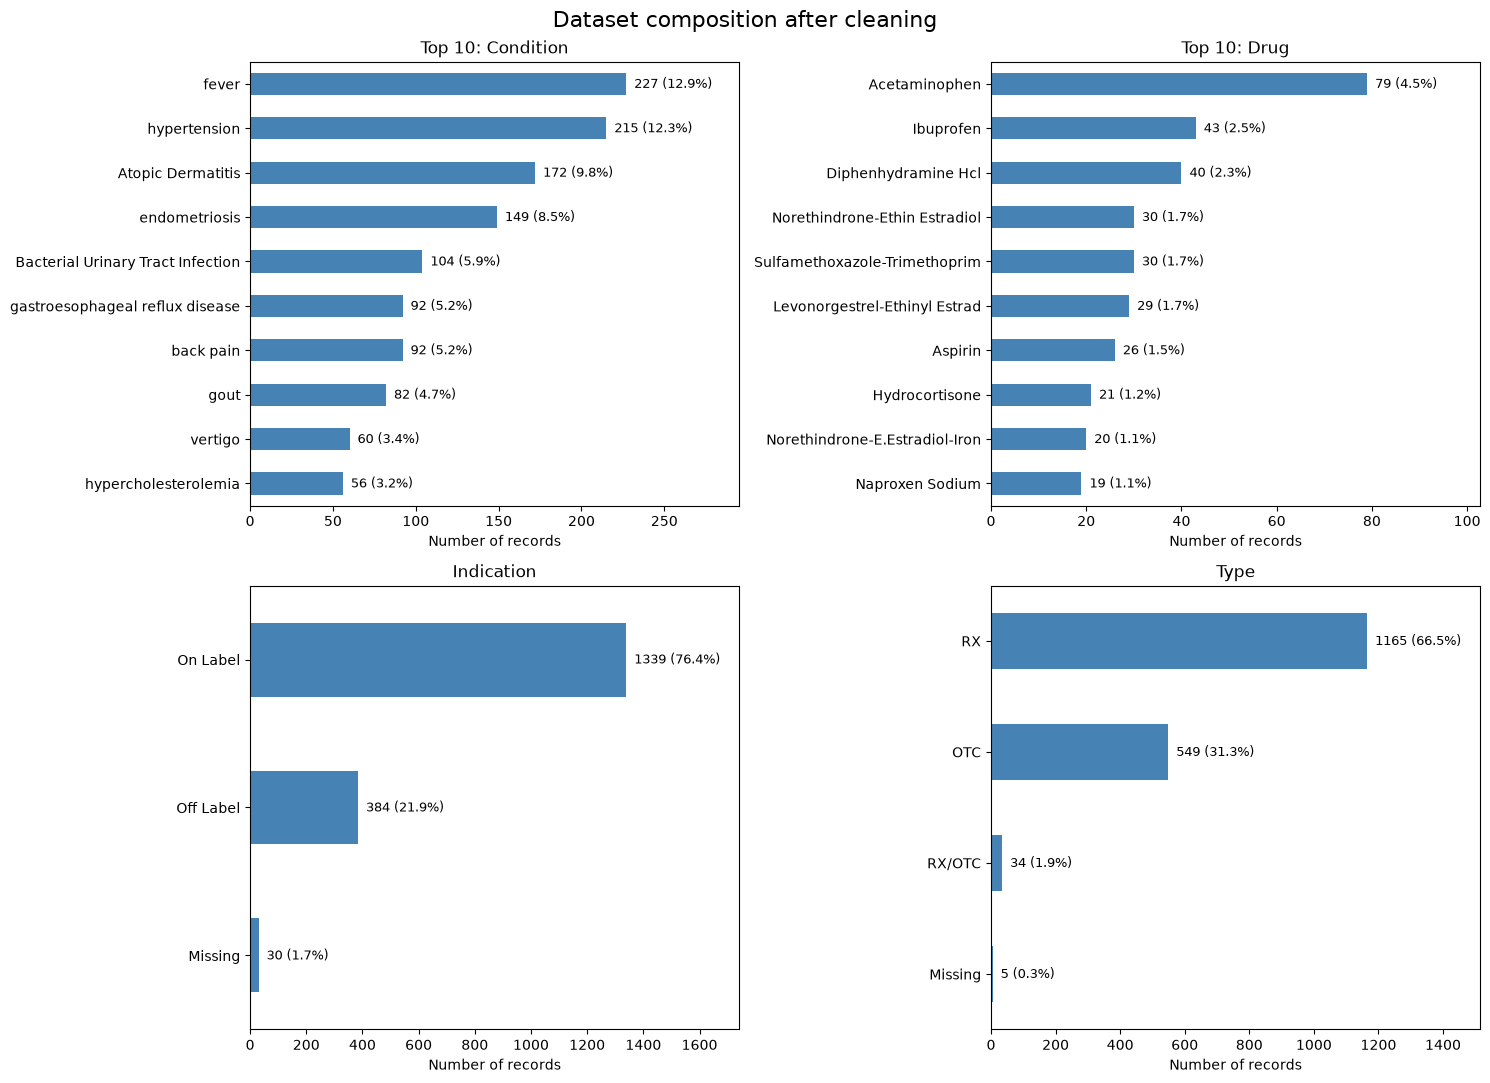

In [71]:
#1.What categories/groups dominate the dataset?

# for column in ["Condition", "Drug", "Indication", "Type"]:
#     counts = df_clean[column].fillna("Missing").value_counts()

#     summary = pd.DataFrame({
#         "Records": counts,
#         "Percent": (counts / len(df_clean) * 100).round(2)
#     })

#     print(f"\n{column} — largest groups:")
#     display(summary.head(10))

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, column in zip(
    axes.flat, ["Condition", "Drug", "Indication", "Type"]
):
    counts = df_clean[column].fillna("Missing").value_counts()
    top_counts = counts.head(10).sort_values()

    top_counts.plot.barh(ax=ax, color="steelblue")

    for position, count in enumerate(top_counts):
        percent = count / len(df_clean) * 100
        ax.text(
            count, position,
            f"  {count} ({percent:.1f}%)",
            va="center", fontsize=9
        )

    title = f"Top 10: {column}" if len(counts) > 10 else column
    ax.set_title(title)
    ax.set_xlabel("Number of records")
    ax.set_ylabel("")
    ax.set_xlim(0, top_counts.max() * 1.3)

fig.suptitle("Dataset composition after cleaning", fontsize=16)
plt.tight_layout()
plt.show()

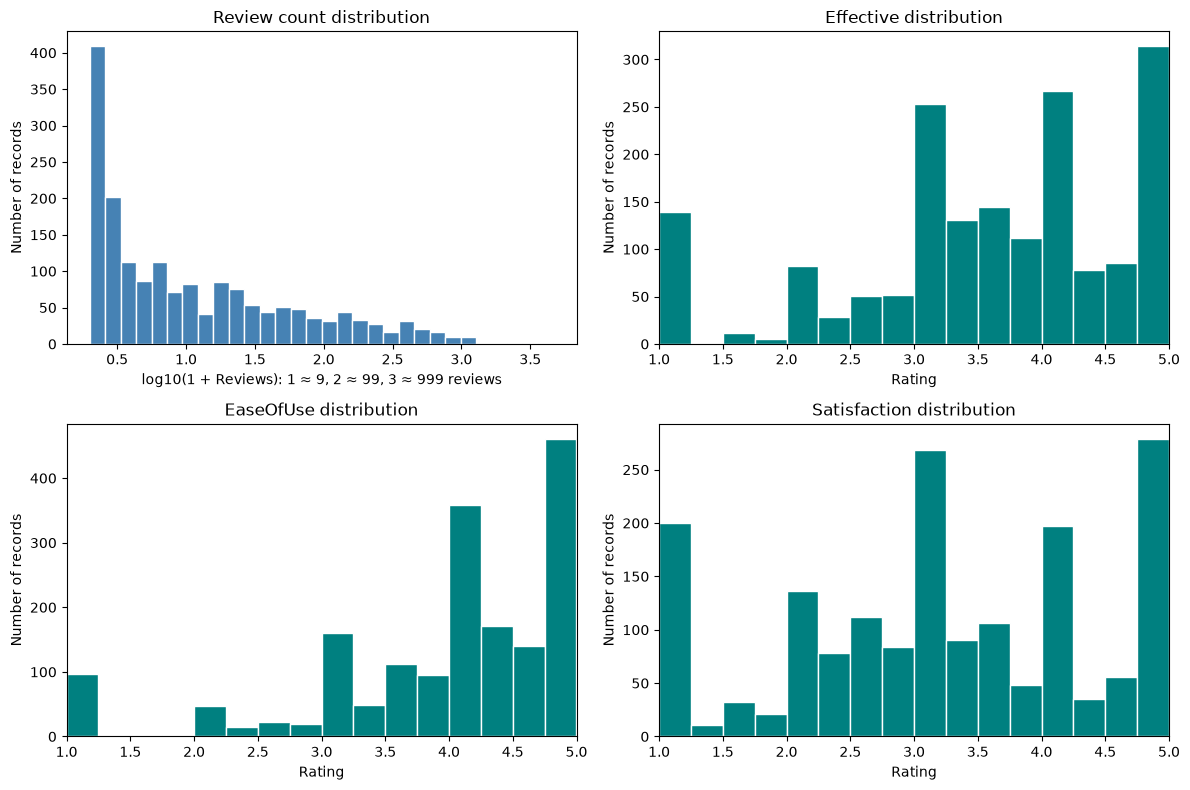

,Reviews,Effective,EaseOfUse,Satisfaction
count,1753.0,1753.00,1753.00,1753.00
mean,64.51,3.54,3.94,3.18
std,227.26,1.12,1.04,1.23
min,1.0,1.00,1.00,1.00
25%,2.0,3.00,3.50,2.34
50%,5.0,3.69,4.08,3.11
75%,30.0,4.33,4.80,4.00
max,4647.0,5.00,5.00,5.00


In [72]:
#Visualise how the numerical variables are distributed

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Review counts often span a much wider range than ratings
reviews = df_clean["Reviews"].dropna().astype(float)
axes[0, 0].hist(
    np.log10(1 + reviews),
    bins=30,
    color="steelblue",
    edgecolor="white"
)
axes[0, 0].set_title("Review count distribution")
axes[0, 0].set_xlabel("log10(1 + Reviews): 1 ≈ 9, 2 ≈ 99, 3 ≈ 999 reviews")

# Use identical bins and axes to compare the rating distributions
rating_columns = ["Effective", "EaseOfUse", "Satisfaction"]

for ax, column in zip(axes.flat[1:], rating_columns):
    ax.hist(
        df_clean[column].dropna(),
        bins=np.linspace(1, 5, 17),
        color="teal",
        edgecolor="white"
    )
    ax.set_title(f"{column} distribution")
    ax.set_xlabel("Rating")
    ax.set_xlim(1, 5)

for ax in axes.flat:
    ax.set_ylabel("Number of records")

plt.tight_layout()
plt.show()

display(df_clean[["Reviews"] + rating_columns].describe().round(2))

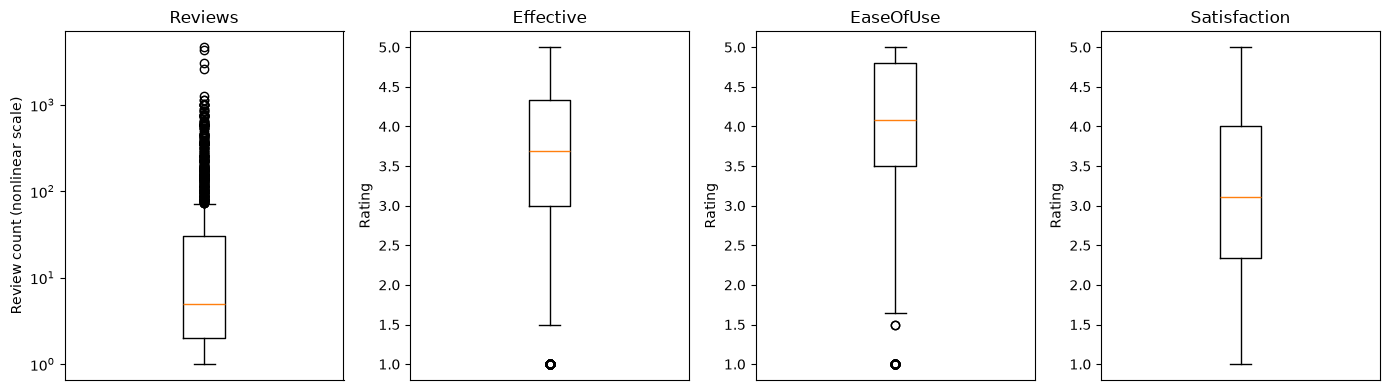

,Variable,Lower boundary,Upper boundary,Flagged records,Flagged %
0,Reviews,-40.00,72.00,281,16.03
1,Effective,1.00,6.32,139,7.93
2,EaseOfUse,1.55,6.75,99,5.65
3,Satisfaction,-0.15,6.49,0,0.00


In [73]:
#Identify potential outliers

numeric_columns = ["Reviews", "Effective", "EaseOfUse", "Satisfaction"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
outlier_summary = []

for ax, column in zip(axes, numeric_columns):
    values = df_clean[column].dropna().astype(float)

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flagged = (values < lower) | (values > upper)

    ax.boxplot(values, showfliers=True)
    ax.set_title(column)
    ax.set_xticks([])

    if column == "Reviews":
        ax.set_yscale("symlog", linthresh=1)
        ax.set_ylabel("Review count (nonlinear scale)")
    else:
        ax.set_ylabel("Rating")

    outlier_summary.append({
        "Variable": column,
        "Lower boundary": lower,
        "Upper boundary": upper,
        "Flagged records": int(flagged.sum()),
        "Flagged %": 100 * flagged.mean()
    })

plt.tight_layout()
plt.show()

display(pd.DataFrame(outlier_summary).round(2))

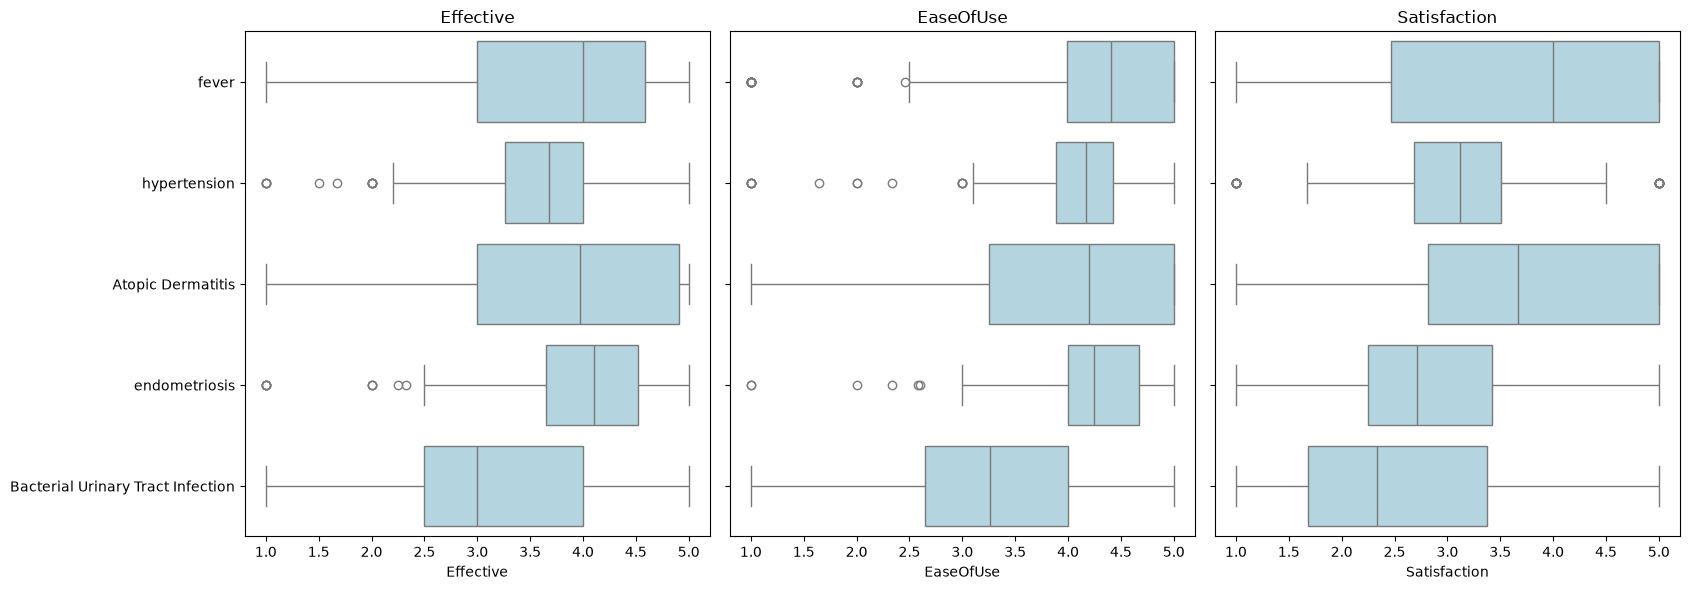

,Records,Median_reviews,Median_effective,Median_ease,Median_satisfaction
Condition,,,,,
fever,227,2.0,4.00,4.41,4.00
hypertension,215,20.0,3.68,4.17,3.12
Atopic Dermatitis,172,4.5,3.97,4.20,3.67
endometriosis,149,13.0,4.10,4.25,2.71
Bacterial Urinary Tract Infection,104,8.5,3.00,3.26,2.33


In [74]:
#How do groups compare?

import seaborn as sns

top_conditions = (
    df_clean["Condition"].value_counts().head(5).index
)

subset = df_clean[df_clean["Condition"].isin(top_conditions)]

fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)

for ax, rating in zip(
    axes, ["Effective", "EaseOfUse", "Satisfaction"]
):
    sns.boxplot(
        data=subset,
        x=rating,
        y="Condition",
        order=top_conditions,
        color="lightblue",
        ax=ax
    )
    ax.set_title(rating)
    ax.set_xlim(0.8, 5.2)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

display(
    subset.groupby("Condition")
    .agg(
        Records=("Drug", "size"),
        Median_reviews=("Reviews", "median"),
        Median_effective=("Effective", "median"),
        Median_ease=("EaseOfUse", "median"),
        Median_satisfaction=("Satisfaction", "median")
    )
    .reindex(top_conditions)
    .round(2)
)

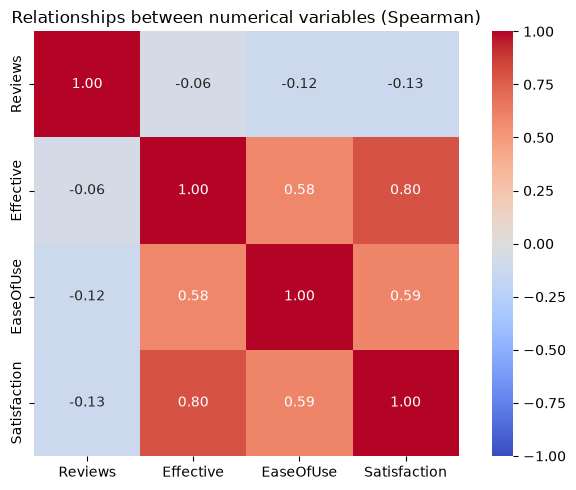

In [75]:
#Are numerical values correlated?

numeric_columns = [
    "Reviews", "Effective", "EaseOfUse", "Satisfaction"
]

correlations = df_clean[numeric_columns].corr(method="spearman")

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Relationships between numerical variables (Spearman)")
plt.tight_layout()
plt.show()


Condition


,Records,Percent
Condition,,
fever,227,12.95
hypertension,215,12.26
Atopic Dermatitis,172,9.81
endometriosis,149,8.50
Bacterial Urinary Tract Infection,104,5.93
back pain,92,5.25
gastroesophageal reflux disease,92,5.25
gout,82,4.68
vertigo,60,3.42



Indication


,Records,Percent
Indication,,
On Label,1339,76.38
Off Label,384,21.91
Missing,30,1.71



Type


,Records,Percent
Type,,
RX,1165,66.46
OTC,549,31.32
RX/OTC,34,1.94
Missing,5,0.29


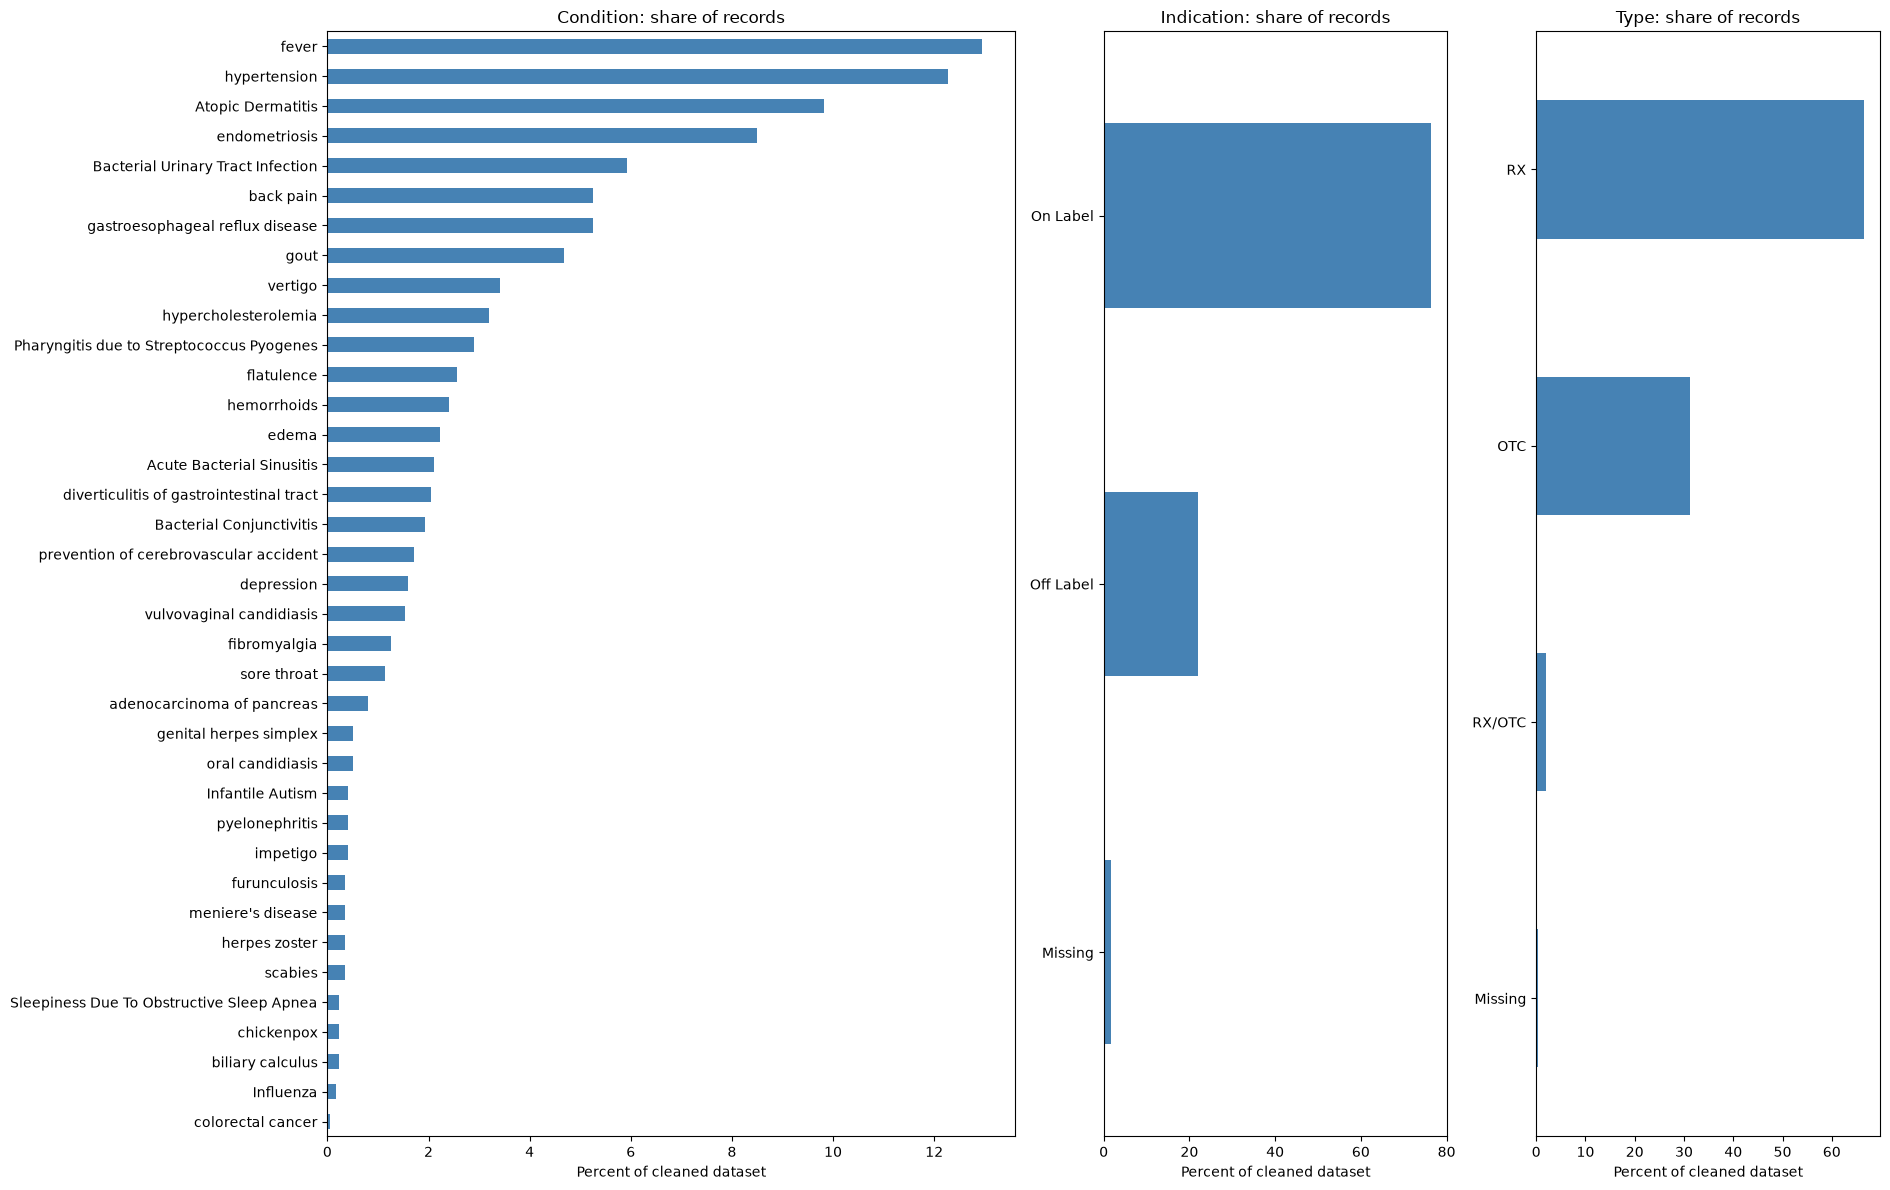

In [76]:
#Are group strongly imbalanced?

columns = ["Condition", "Indication", "Type"]
fig, axes = plt.subplots(
    1, 3, figsize=(19, 12),
    gridspec_kw={"width_ratios": [2, 1, 1]}
)

for ax, column in zip(axes, columns):
    counts = df_clean[column].fillna("Missing").value_counts()
    percentages = counts / len(df_clean) * 100

    percentages.sort_values().plot.barh(
        ax=ax, color="steelblue"
    )

    ax.set_title(f"{column}: share of records")
    ax.set_xlabel("Percent of cleaned dataset")
    ax.set_ylabel("")

    print(f"\n{column}")
    display(pd.DataFrame({
        "Records": counts,
        "Percent": percentages.round(2)
    }))

plt.tight_layout()
plt.show()

### EDA findings Summary

- The cleaned dataset contains 1,753 records after removing 466 exact duplicates.
- Review counts are strongly right-skewed: many records have few reviews,
  while a minority have very large counts.
- Ease-of-use ratings tend toward the upper end of the observed 1–5 range.
- The IQR method flags high review counts and some low ratings.
  These were retained because statistical outliers are not necessarily errors.
- Rating distributions differ across conditions.
- Effectiveness and satisfaction have a strong positive Spearman
  correlation (0.80); this does not establish causation.
- Dataset coverage is uneven across conditions, indication categories,
  and drug types.
- Missing values remain in Indication (30) and Type (5).
- Results describe dataset records, not patient counts, prescribing
  frequency, or condition prevalence.

### Retreival

In [77]:
# Prepare a separate dataset for retrieval
df_vector = df_clean.copy()

df_vector["document"] = (
    "Condition: " + df_vector["Condition"].fillna("") + "\n"
    + "Drug: " + df_vector["Drug"].fillna("") + "\n"
    + "Information: " + df_vector["Information"].fillna("")
)

print(df_vector["document"].iloc[111])

Condition: Atopic Dermatitis
Drug: Hydrocortisone-Pramoxine, Hydrocortisone
Information: This medication is used to treat a variety of skin conditions (e.g., insect bites, poison oak/ivy, eczema, dermatitis, allergies, rash, itching of the outer female genitals, anal itching). This is a generic drug. The average cash price for 1 Tube, 28.35gm of 2.5% each of the generic (hydrocortisone) is $14.59. You can buy hydrocortisone at the discounted price of $9.11 by using the WebMDRx coupon, a savings of 38%. Even if this drug is covered by Medicare or your insurance, we recommend you compare prices. The WebMDRx coupon or cash price may be less than your co-pay.


In [78]:
columns = ["Condition", "Drug", "Information"]

print("Total rows:", len(df_vector))

print("\nMissing or blank values:")
for column in columns:
    values = df_vector[column].astype("string")
    missing = values.fillna("").str.strip().eq("")
    print(f"{column}: {missing.sum()}")

print(
    "\nDuplicate records:",
    df_vector.duplicated(subset=columns).sum()
)

Total rows: 1753

Missing or blank values:
Condition: 0
Drug: 0
Information: 0

Duplicate records: 1129


In [79]:
df_vector = (
    df_vector
    .drop_duplicates(subset=["Condition", "Drug", "Information"])
    .reset_index(drop=True)
    .copy()
)

print("Unique retrieval records:", len(df_vector))

Unique retrieval records: 624


In [80]:
row = df_vector.iloc[0]

document = {
    "id": f"drug_{row.name}",
    "document_text": row["document"],
    "metadata": {
        "condition": row["Condition"],
        "drug": row["Drug"],
        "information": row["Information"],
    },
}

print("TEXT TO EMBED:")
print(document["document_text"])

print("\nMETADATA TO RETURN:")
for key, value in document["metadata"].items():
    print(f"{key}: {value}")

TEXT TO EMBED:
Condition: Acute Bacterial Sinusitis
Drug: Levofloxacin
Information: Levofloxacin is used to treat a variety of bacterial infections. This is a generic drug. The average cash price for 10 Tablet(s), 500mg each of the generic (levofloxacin) is $172.99. You can buy levofloxacin at the discounted price of $47.08 by using the WebMDRx coupon, a savings of 73%. Even if this drug is covered by Medicare or your insurance, we recommend you compare prices. The WebMDRx coupon or cash price may be less than your co-pay.

METADATA TO RETURN:
condition: Acute Bacterial Sinusitis
drug: Levofloxacin
information: Levofloxacin is used to treat a variety of bacterial infections. This is a generic drug. The average cash price for 10 Tablet(s), 500mg each of the generic (levofloxacin) is $172.99. You can buy levofloxacin at the discounted price of $47.08 by using the WebMDRx coupon, a savings of 73%. Even if this drug is covered by Medicare or your insurance, we recommend you compare prices.

In [81]:
row = df_vector.iloc[0]

document = {
    "id": f"drug_{row.name}",
    "document_text": (
        f"Condition: {row['Condition']}\n"
        f"Drug: {row['Drug']}\n"
        f"Information: {row['Information']}"
    ),
    "metadata": {
        "condition": row["Condition"],
        "drug": row["Drug"],
        "information": row["Information"],
    },
}

print("TEXT TO EMBED:")
print(document["document_text"])

print("\nMETADATA TO RETURN:")
for key, value in document["metadata"].items():
    print(f"{key}: {value}")

TEXT TO EMBED:
Condition: Acute Bacterial Sinusitis
Drug: Levofloxacin
Information: Levofloxacin is used to treat a variety of bacterial infections. This is a generic drug. The average cash price for 10 Tablet(s), 500mg each of the generic (levofloxacin) is $172.99. You can buy levofloxacin at the discounted price of $47.08 by using the WebMDRx coupon, a savings of 73%. Even if this drug is covered by Medicare or your insurance, we recommend you compare prices. The WebMDRx coupon or cash price may be less than your co-pay.

METADATA TO RETURN:
condition: Acute Bacterial Sinusitis
drug: Levofloxacin
information: Levofloxacin is used to treat a variety of bacterial infections. This is a generic drug. The average cash price for 10 Tablet(s), 500mg each of the generic (levofloxacin) is $172.99. You can buy levofloxacin at the discounted price of $47.08 by using the WebMDRx coupon, a savings of 73%. Even if this drug is covered by Medicare or your insurance, we recommend you compare prices.

In [82]:
document["embedding"] = None

assert isinstance(document["id"], str)
assert isinstance(document["document_text"], str)
assert document["document_text"].strip()

for field in ["condition", "drug", "information"]:
    value = document["metadata"][field]
    assert isinstance(value, str), f"{field} must be text"
    assert value.strip(), f"{field} must not be blank"

print("Document matches the schema.")

Document matches the schema.


In [83]:
import sys
print(sys.executable)

from openai import OpenAI
print("OpenAI import works!")

c:\Users\suvra_nw8ieuf\AppData\Local\uv-envs\Drug_Assist\Scripts\python.exe
OpenAI import works!


In [103]:
from dotenv import load_dotenv
import os

load_dotenv(
    r"C:\Users\suvra_nw8ieuf\OneDrive\Desktop\Drug_Assist\.env",
    override=True,
)

key_loaded = bool(os.getenv("OPENAI_API_KEY", "").strip())
print("API key loaded:", key_loaded)

API key loaded: True


In [104]:
from openai import OpenAI

client = OpenAI(timeout=30.0, max_retries=0)

response = client.embeddings.create(
    model="text-embedding-3-small",
    input=document["document_text"],
)

document["embedding"] = response.data[0].embedding

print("Embedding created!")

Embedding created!


In [105]:
print("Number of dimensions:", len(document["embedding"]))
print("First 5 numbers:", document["embedding"][:5])

Number of dimensions: 1536
First 5 numbers: [-0.0577392578125, -0.04132080078125, 0.00421142578125, 0.03704833984375, -0.01739501953125]


In [107]:
import os
from pathlib import Path
import chromadb

# Store the database on your computer, outside OneDrive
db_path = Path(os.environ["LOCALAPPDATA"]) / "Drug_Assist" / "chroma"
db_path.mkdir(parents=True, exist_ok=True)

chroma_client = chromadb.PersistentClient(path=str(db_path))

print("ChromaDB ready!")
print("Storage location:", db_path)

ChromaDB ready!
Storage location: C:\Users\suvra_nw8ieuf\AppData\Local\Drug_Assist\chroma


In [108]:
collection = chroma_client.get_or_create_collection(
    name="drug_documents",
    embedding_function=None,
    configuration={"hnsw": {"space": "cosine"}},
)

print("Collection:", collection.name)
print("Documents stored:", collection.count())

Collection: drug_documents
Documents stored: 0


In [109]:
documents = [
    {
        "id": f"drug_{i}",
        "document_text": row["document"],
        "metadata": {
            "condition": row["Condition"],
            "drug": row["Drug"],
            "information": row["Information"],
        },
    }
    for i, row in df_vector.iterrows()
]

print("Documents prepared:", len(documents))
print("First document:", documents[0])

Documents prepared: 624
First document: {'id': 'drug_0', 'document_text': 'Condition: Acute Bacterial Sinusitis\nDrug: Levofloxacin\nInformation: Levofloxacin is used to treat a variety of bacterial infections. This is a generic drug. The average cash price for 10 Tablet(s), 500mg each of the generic (levofloxacin) is $172.99. You can buy levofloxacin at the discounted price of $47.08 by using the WebMDRx coupon, a savings of 73%. Even if this drug is covered by Medicare or your insurance, we recommend you compare prices. The WebMDRx coupon or cash price may be less than your co-pay.', 'metadata': {'condition': 'Acute Bacterial Sinusitis', 'drug': 'Levofloxacin', 'information': 'Levofloxacin is used to treat a variety of bacterial infections. This is a generic drug. The average cash price for 10 Tablet(s), 500mg each of the generic (levofloxacin) is $172.99. You can buy levofloxacin at the discounted price of $47.08 by using the WebMDRx coupon, a savings of 73%. Even if this drug is co

In [110]:
batch_size = 100

# Skip documents already embedded if you rerun this cell
pending = [
    doc for doc in documents
    if doc.get("embedding") is None
]

for start in range(0, len(pending), batch_size):
    batch = pending[start:start + batch_size]

    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=[doc["document_text"] for doc in batch],
    )

    for result in response.data:
        batch[result.index]["embedding"] = result.embedding

    completed = sum(
        doc.get("embedding") is not None
        for doc in documents
    )
    print(f"Embedded {completed}/{len(documents)}", flush=True)

Embedded 100/624
Embedded 200/624
Embedded 300/624
Embedded 400/624
Embedded 500/624
Embedded 600/624
Embedded 624/624


In [111]:
collection.upsert(
    ids=[doc["id"] for doc in documents],
    documents=[doc["document_text"] for doc in documents],
    embeddings=[doc["embedding"] for doc in documents],
    metadatas=[doc["metadata"] for doc in documents],
)

print("Documents stored:", collection.count())

Documents stored: 624


In [119]:
query = "medicines for depression"

# Turn the search phrase into an embedding
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=query,
)

query_embedding = response.data[0].embedding

# Find the three closest documents
results = collection.query(
    query_embeddings=[query_embedding],
    n_results=3,
    include=["documents", "metadatas", "distances"],
)

# Display the matches
for i, metadata in enumerate(results["metadatas"][0]):
    print(f"Match {i + 1}")
    print("Drug:", metadata["drug"])
    print("Condition:", metadata["condition"])
    print("Distance:", round(results["distances"][0][i], 4))
    print("Text:", results["documents"][0][i])
    print()

Match 1
Drug: Amitriptyline
Condition: depression
Distance: 0.4848
Text: Condition: depression
Drug: Amitriptyline
Information: This medication is used to treat mental/mood problems such as depression. This is a generic drug. You can buy amitriptyline hcl at the discounted price of $11.49 by using the WebMDRx coupon. Even if this drug is covered by Medicare or your insurance, we recommend you compare prices. The WebMDRx coupon or cash price may be less than your co-pay.

Match 2
Drug: Imipramine Hcl
Condition: depression
Distance: 0.5232
Text: Condition: depression
Drug: Imipramine Hcl
Information: This medication is used to treat depression. This is a generic drug. You can buy imipramine hcl at the discounted price of $11.80 by using the WebMDRx coupon. Even if this drug is covered by Medicare or your insurance, we recommend you compare prices. The WebMDRx coupon or cash price may be less than your co-pay.

Match 3
Drug: Nortriptyline
Condition: depression
Distance: 0.524
Text: Condit

In [125]:
filtered_results = collection.query(
    query_embeddings=[query_embedding],
    n_results=3,
    where={"condition": "depression"},
    include=["documents", "metadatas", "distances"],
)

for metadata, distance in zip(
    filtered_results["metadatas"][0],
    filtered_results["distances"][0],
):
    print(
        metadata["drug"],
        "|", metadata["condition"],
        "| Distance:", round(distance, 5),
    )

Amitriptyline | depression | Distance: 0.48477
Imipramine Hcl | depression | Distance: 0.52324
Nortriptyline | depression | Distance: 0.52397


In [126]:
expected_condition = "depression"

matches = results["metadatas"][0]

correct = sum(
    item["condition"] == expected_condition
    for item in matches
)

precision = correct / len(matches) if matches else 0

print(f"Expected-condition matches: {correct}/{len(matches)}")
print(f"Precision@3: {precision:.0%}")

Expected-condition matches: 3/3
Precision@3: 100%
